In [42]:
import numpy as np
import matplotlib.pyplot as plt

In [43]:
face_value = 100
coupon_rate = 0.05
print(face_value)
print (coupon_rate)

100
0.05


In [44]:
def add_interest(amount, rate):
    result = amount * (1+ rate)
    return result

new_amount = add_interest (100,0.05)
print (new_amount)

105.0


In [45]:
print (2 ** 3)
print (1.05 ** 5)

8
1.2762815625000004


In [46]:
for year in range (1,4):
    print ("Year", year)


Year 1
Year 2
Year 3


In [47]:
total = 0.0
for year in range (1,4):
    total = total + 10
print (total)

30.0


In [48]:
price = 0.0
for year in range(1, 6):
    payment = 10
    print(f"Year {year}: add £{payment}, total is now £{price + payment}")
    price = price + payment
print(f"Final price: £{price}")

Year 1: add £10, total is now £10.0
Year 2: add £10, total is now £20.0
Year 3: add £10, total is now £30.0
Year 4: add £10, total is now £40.0
Year 5: add £10, total is now £50.0
Final price: £50.0


In [49]:
def survival_prob(hazard, t):
    """Probability the borrower is still alive at time t."""
    return np.exp(-hazard * t)

def hazard_from_spread(spread, recovery):
    """Credit triangle: hazard approx = spread / (1 - recovery)."""
    return spread / (1 - recovery)

In [50]:
def cds_legs(hazard, recovery, maturity, rate, freq=4):
    n= int(round(maturity*freq))
    dt = 1/freq
    rpv01 = 0.0
    protection = 0.0
    prev_surv = 1.0
    for i in range (1, n+1):
        t = i * dt
        df = np.exp(-rate *t)
        surv = survival_prob (hazard, t)
        rpv01 = rpv01 + df * surv * dt
        protection = protection + df * (prev_surv -surv) * (1-recovery)
        prev_surv = surv
    return rpv01, protection

In [51]:
def par_spread(hazard, recovery, maturity, rate, freq=4):
    """Fair spread to make both legs equal. Calling function from previous line."""
    rpv01, protection = cds_legs(hazard, recovery, maturity, rate, freq)
    return protection/rpv01 

def cds_value (notional, contract_spread, hazard, recovery, maturity, rate, freq=4):
    """Value of CDS to protection buyer."""
    rpv01, protection = cds_legs (hazard,recovery, maturity, rate, freq)
    return notional * (protection- contract_spread * rpv01)


In [52]:
recovery, rate, maturity = 0.4, 0.03, 5
h= hazard_from_spread(0.01, recovery)

ps = par_spread (h, recovery, maturity, rate)
print ("Par spread (bps): ", round (ps *10000, 1))

v_par = cds_value(10_000_000, ps, h, recovery, maturity, rate)
print("Value of par CDS:", round(v_par, 2)) 

v_cheap = cds_value(10_000_000, 0.0080, h, recovery, maturity, rate)
print("Bought protection at 80bps:", round(v_cheap, 2)) 

Par spread (bps):  100.2
Value of par CDS: 0.0
Bought protection at 80bps: 89595.86


In [53]:
def cs01 (notional, contract_spread, spread_now, recovery, maturity, rate, freq= 4):
    """Value change of the protection buyer for a +1bp spread move."""
    h0= hazard_from_spread (spread_now, recovery)
    h1= hazard_from_spread (spread_now+ 0.0001, recovery)
    v0 = cds_value (notional, contract_spread, h0, recovery, maturity, rate, freq)
    v1 = cds_value (notional, contract_spread, h1, recovery, maturity, rate, freq)
    print (round (v0,2))
    print (round (v1,2))

    return v1-v0

risk = cs01 (10_000_000, 0.0080, 0.0100, 0.40, 5, 0.03)
print ("CS01:", round(risk,2))
"""This shows that when spread widens, the protection position for the buyer is more valuable."""


89595.86
94008.4
CS01: 4412.53


'This shows that when spread widens, the protection position for the buyer is more valuable.'

In [56]:
def scenario(notional, contract_spread, base_spread, recovery, maturity, rate, shock_bps):
    """Reprice after shocking the credit spread by shock_bps basis points."""
    new_spread = base_spread + shock_bps / 10000
    h= hazard_from_spread (new_spread, recovery)
    return cds_value(notional, contract_spread, h, recovery, maturity, rate)

base = 0.0100
shocks= [-50, -25, 0, 25, 50, 100]
print ("Shock (bps) | Position value")
for s in shocks:
    v= scenario (10_000_000, 0.0080, base, 0.40, 5, 0.03, s)
    print (f"{s:+5d}       | {v:,.2f}")

Shock (bps) | Position value
  -50       | -135,612.00
  -25       | -21,877.26
   +0       | 89,595.86
  +25       | 198,853.16
  +50       | 305,939.49
 +100       | 513,774.06


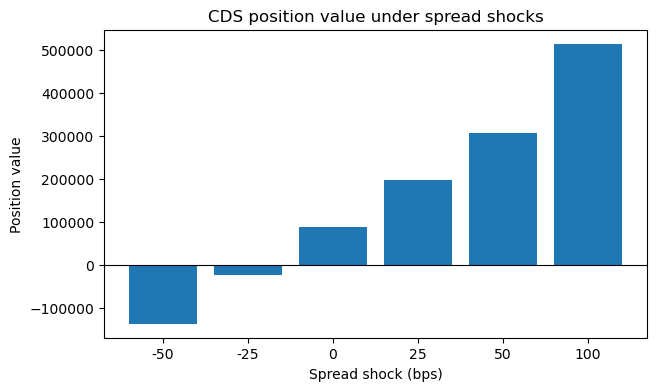

In [55]:
values = [scenario(10_000_000, 0.0080, base, 0.40, 5, 0.03, s) for s in shocks]
plt.figure(figsize=(7, 4))
plt.bar([str(s) for s in shocks], values)
plt.title("CDS position value under spread shocks")
plt.xlabel("Spread shock (bps)")
plt.ylabel("Position value")
plt.axhline(0, color="black", linewidth=0.8)
plt.show()